# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters? <br><br>
MSE squares the difference between the predicted and actual y value. By adding a penalty to MSE for particlar features, it reduces the sensitivty of the model for features that have larger weights as it would increases the error proportionally to how influencial the coefficient is of that feature.<br>

2. How does regularization provide a way of exploring the bias-variance trade-off?<br><br>
By adding the penalty, we are balencing the amount of influence features should have on prediction with the penalized error they bring. The bias is assumptions made from simplifying the data (underfitting) and variance is the sensitity of the model because of how the features impact the prediction (overfitting). Balencing these can be done through finding the minimum MSE with penalty. <br>

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?<br><br>
Both regression models use penalties to balence between bias and variance. Lasso regression uses an absolute value of the coefficients as a penalty whereas ridge regression uses the square of the coefficients. Lasso regressions performs feature selection as less influencial features are eliminated when their coefficient set to zero. Ridge does not do this as the coefficients are only reduced, not eliminated. Because of this difference, Lasso produces a much simpler model with necessary features, and ridge includes all features even though they are reduced. <br>

4. How do we typically scale variables for use in regularized regression? Why?<br><br>
We scale by the z score (StandardScaling) before fitting the model and adding the penalties. We do this because we want to equally evaluate the amount of influence that each feature has on the prediction so when we add our penalty it will justly/equally effect each coefficient. <br>

5. How is the penalty $\alpha$ typically selected?<br><br>
The alpha where the loss function is the smallest is the best alpha for predictions. Cross validation determines the accuracy of the model's prediction by comparing the predicted to the actual value. We can use the cross-validation to find the alpha that minimzed the cross validation MSE when fitting the model. <br>

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?<br><br>
No. Including penalty to the model allows us to determine the best alpha to use for the most accurate model with training data when we are fitting the model. When we run this model on testing data, we do not use a penalty term for cross validation because we are evaluating the predictions based on the current model being run. 
<br>

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [461]:
# Q 2.1
import pandas as pd
import numpy as np

df = pd.read_csv('./data/cars_hw.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 91.6+ KB


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [462]:
# Q 2.1

df['Age'] = 2026 - df['Make_Year']
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [463]:
# Q 2.1

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

x = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree = 3, include_bias = False)
x_poly = poly.fit_transform(x)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_poly)


print(poly.get_feature_names_out())
print(x_scaled)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
[[ 0.12469203 -0.01309242 -0.13767332 ... -0.23076715 -0.19558597
  -0.27042227]
 [-0.87233418  0.34185769 -0.79131562 ... -0.71818608 -0.56489035
   0.04408937]
 [-0.49351672 -0.72299265 -0.60062321 ... -0.64800377 -0.70091085
  -0.71839826]
 ...
 [ 0.46248973  1.05175792  0.19479598 ...  0.32073381  0.73673979
   0.88897673]
 [-0.54294553 -1.07794277 -0.62951357 ... -0.69364241 -0.80062127
  -0.86578933]
 [-0.01621083 -0.36804254 -0.25974731 ... -0.38445401 -0.42380175
  -0.52226369]]


In [464]:
# # Q 2.2


from sklearn.linear_model import LinearRegression

y = df['Price']

model_lr = LinearRegression()
model_lr = model_lr.fit(x_scaled, y)

model_table = pd.DataFrame({'var':poly.get_feature_names_out(['Mileage_Run', 'Age']), 'coef':model_lr.coef_ })
model_table

#the sign for the interaction between Mileage_Run and Age is negative,
# as shown in the coeficient for the variable Mileage_Run*Age which is -1.67e+06


,var,coef
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


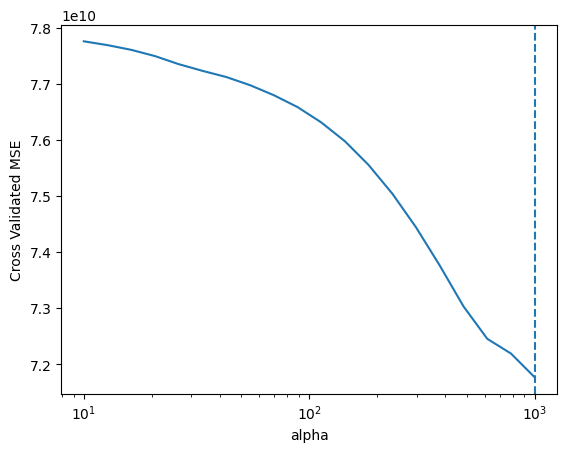

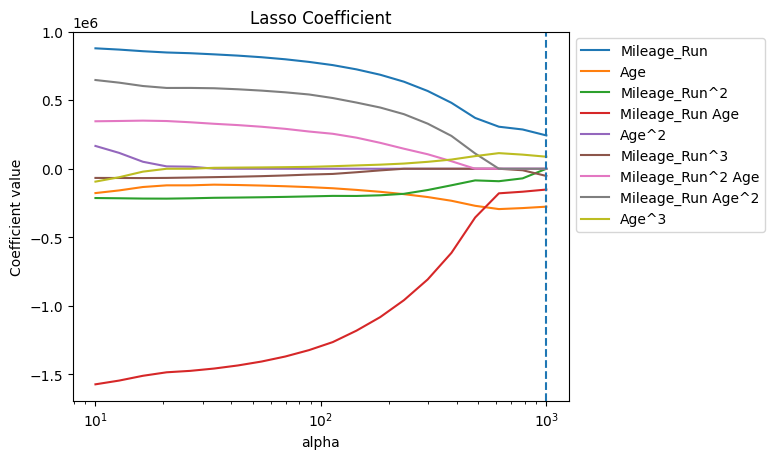

In [465]:
# Q 2.3

from sklearn.linear_model import LassoCV, Lasso, lasso_path
import matplotlib.pyplot as plt
import seaborn as sns

alpha_grid = np.logspace(1, 3, 20)
model_lassocv = LassoCV(cv = 20, alphas = alpha_grid, random_state = 100, max_iter=50000)
model_lassocv = model_lassocv.fit(x_scaled, y)


index_star = np.argmin(np.median(model_lassocv.mse_path_,axis=1))
alpha_star = model_lassocv.alphas_[index_star]

# Q 2.4

sns.lineplot( x=model_lassocv.alphas_, y= np.median(model_lassocv.mse_path_,axis=1))
plt.axvline(x=alpha_star, linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
plt.show()

# Q 2.5 

coefs = []
for alpha in alpha_grid:
    model_lasso = Lasso(alpha = alpha, max_iter= 100000)
    model_lasso = model_lasso.fit(x_scaled, y)
    coefs.append(model_lasso.coef_)
coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly.get_feature_names_out(['Mileage_Run', 'Age'])[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient")
plt.axvline(x=alpha_star, linestyle='--')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()



In [466]:
model_lasso_star = Lasso(alpha = 0.012689610031679234, max_iter= 100000)
model_lasso_star = model_lasso_star.fit(x_scaled, y)
poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit(x)


zero_coef = {}
selected_feature = {}
feature_names = poly.get_feature_names_out(x.columns)

for coef, name in zip(model_lasso_star.coef_, feature_names):
    if coef == 0:
        zero_coef.update({name:coef})
    else:
        selected_feature.update({name:coef})

print(selected_feature)
print(zero_coef)
print(alpha_star)
print(index_star)

{'Mileage_Run': np.float64(911732.2794238959), 'Age': np.float64(-248082.52631461478), 'Mileage_Run^2': np.float64(-207300.3958015336), 'Mileage_Run Age': np.float64(-1671086.705985125), 'Age^2': np.float64(350317.415018587), 'Mileage_Run^3': np.float64(-65147.08696792791), 'Mileage_Run^2 Age': np.float64(338828.72482310707), 'Mileage_Run Age^2': np.float64(716693.4275888049), 'Age^3': np.float64(-209890.76339723135)}
{}
1000.0
0


Q 2.6 <br>
There were no features where their coefficent reduced to zero, thus elimiating them. This is because the features are extremely correlated as they all are only dependent on Mileage_Run and Age. All the features were thus selected. 

In [467]:
lasso_merged = selected_feature | zero_coef
lasso_table = pd.DataFrame.from_dict(lasso_merged, orient='index', columns=['Value'])

print(lasso_table)
print(model_table)

                          Value
Mileage_Run        9.117323e+05
Age               -2.480825e+05
Mileage_Run^2     -2.073004e+05
Mileage_Run Age   -1.671087e+06
Age^2              3.503174e+05
Mileage_Run^3     -6.514709e+04
Mileage_Run^2 Age  3.388287e+05
Mileage_Run Age^2  7.166934e+05
Age^3             -2.098908e+05
                 var          coef
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05


Q 2.7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

The values of the coefficients change very slightly where the coefficients of the linear model are slightly higher (e.g. Mileage_Run in the lasso model has a coefficient of 9.117323e+05 where in the linear mode it is 9.117748e+05). However, none of the coefficients switch signs. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [468]:
df = pd.read_csv('../undergrad_ml/data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [469]:
# Q 3.1

#polyfeat with interaction default False
x = df[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree = 3, include_bias = False)
x_ploy = poly.fit_transform(x)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_ploy)


#polyfeat with interaction = True and dummy vars
x_dum = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_dum = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
x_inter_dum = poly_dum.fit_transform(x_dum) 

#Concatenate these models
x_combined = np.hstack([x_scaled, x_dum, x_inter_dum])
print(x_combined)

[[ 1.19294523 -1.53055953  0.49005699 ...  0.          0.
   0.        ]
 [-0.49127928 -0.00707675 -0.28455235 ...  0.          0.
   0.        ]
 [ 0.35083298 -1.53055953 -0.09090002 ...  0.          0.
   0.        ]
 ...
 [-1.33339153  1.85495776 -0.57503085 ...  0.          0.
   0.        ]
 [-1.33339153 -0.00707675  0.00592615 ...  0.          0.
   0.        ]
 [-0.9123354   0.58538877  0.19957848 ...  0.          0.
   0.        ]]


In [470]:
# Q 3.2


y = df['DEATH_EVENT']

model = LinearRegression()
model = model.fit(x_combined, y)

names_x = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
names_x_inter_dum = poly_dum.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
names_xdum = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

feature_names = np.concatenate([names_x, names_xdum, names_x_inter_dum])
x_combined_df = pd.DataFrame(x_combined, columns=feature_names)

linear_table = pd.DataFrame(model.coef_, index = feature_names, )
linear_table

,0
age,1.539156
ejection_fraction,-2.192494
serum_creatinine,-0.853588
age^2,-3.678654
age ejection_fraction,-0.600918
age serum_creatinine,1.841563
ejection_fraction^2,3.430976
ejection_fraction serum_creatinine,2.673394
serum_creatinine^2,-2.647041
age^3,1.993135


Anaemia, anaemia and diabetes, anaemia and smoking are all slightly above zero. Because these values are very small, the data the model is looking at indicate that this set had no high correlation of anaemia to death. This is only fitted to the training data so it is not clear. Additionally, Age^2 is a very large magnitude and also negative. This is not intuitive for me because age by itself is large and positive (older people are more likely to die in general), however, Age^2 may be large and negative because it acts as a second derivative and shows that age increases at a slower rate as you get older. 

In [471]:
#3.3

alpha_grid = np.logspace(-5, 5, 30)
model_lassocv_health = LassoCV(cv = 20, alphas = alpha_grid, random_state = 42, max_iter = 10000)
model_lassocv_health = model_lassocv_health.fit(x_combined, y)

index_star = np.argmin(np.median(model_lassocv_health.mse_path_,axis=1))
alpha_star = model_lassocv_health.alphas_[index_star]
print(index_star)
print(alpha_star)



/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.166e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.019e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.955e+00, toleran

20
0.012689610031679234


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.517e-01, tolerance: 6.255e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.234e+00, tolerance: 6.255e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.220e+00, toleran

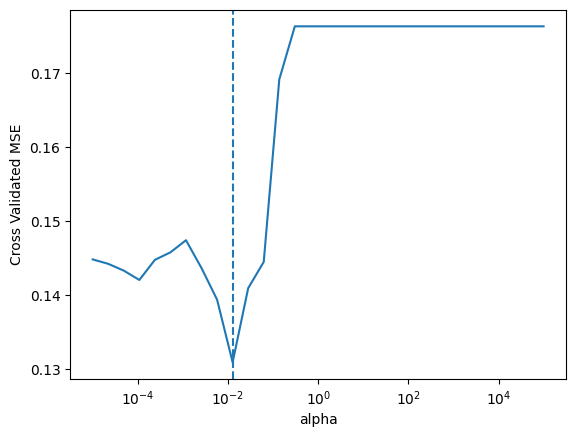

In [472]:
# 3.4


sns.lineplot( x=model_lassocv_health.alphas_, y= np.median(model_lassocv_health.mse_path_,axis=1))
plt.axvline(x=alpha_star, linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
plt.show()

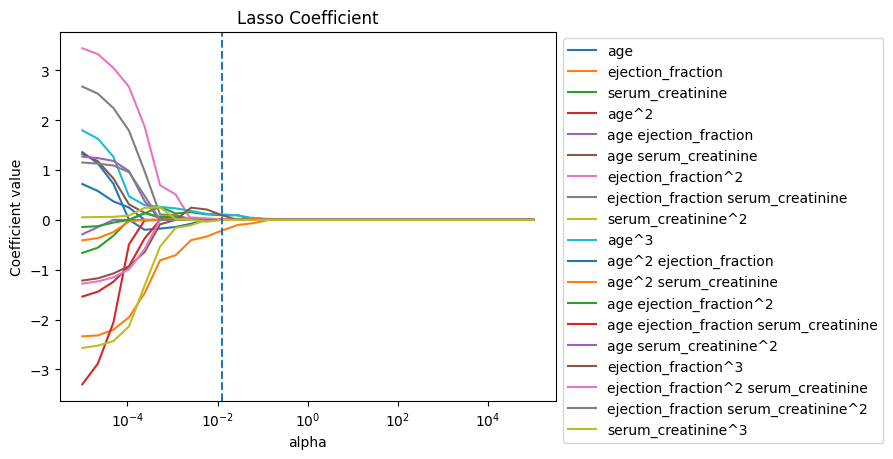

In [473]:
# 3.5

coefs = []
for alpha in alpha_grid:
    model_lasso_health = Lasso(alpha = alpha, max_iter= 100000)
    model_lasso_health = model_lasso_health.fit(x_scaled, y)
    coefs.append(model_lasso_health.coef_)
coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient")
plt.axvline(x=alpha_star, linestyle='--')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [474]:
# Q 3.6

model_lasso_health_star = Lasso(alpha = 0.012689610031679234, max_iter= 100000)
model_lasso_health_star = model_lasso_health_star.fit(x_scaled, y)
poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit(x)


x_combined_df = pd.DataFrame(x_combined, columns=feature_names)

zero_coef = {}
selected_feature = {}
feature_names = x_combined_df.columns


for coef, name in zip(model_lasso_health_star.coef_, feature_names):
    if coef == 0:
        zero_coef.update({name:coef})
    else:
        selected_feature.update({name:coef})

print(f"There are {len(selected_feature)} selected features. The features selected are {selected_feature}")
print(f"There are {len(zero_coef)} features with a zero coefficient. The features that were elimated with a zero coefficient are {zero_coef}")


There are 5 selected features. The features selected are {'ejection_fraction': np.float64(-0.21111435810591217), 'serum_creatinine': np.float64(0.09423745651193666), 'age^3': np.float64(0.11076020080828373), 'ejection_fraction^3': np.float64(0.09266811584939315), 'ejection_fraction^2 serum_creatinine': np.float64(0.011562990437952865)}
There are 14 features with a zero coefficient. The features that were elimated with a zero coefficient are {'age': np.float64(0.0), 'age^2': np.float64(0.0), 'age ejection_fraction': np.float64(-0.0), 'age serum_creatinine': np.float64(0.0), 'ejection_fraction^2': np.float64(0.0), 'ejection_fraction serum_creatinine': np.float64(0.0), 'serum_creatinine^2': np.float64(-0.0), 'age^2 ejection_fraction': np.float64(0.0), 'age^2 serum_creatinine': np.float64(0.0), 'age ejection_fraction^2': np.float64(0.0), 'age ejection_fraction serum_creatinine': np.float64(0.0), 'age serum_creatinine^2': np.float64(-0.0), 'ejection_fraction serum_creatinine^2': np.float64(

In [475]:
# Q 3.6
lasso_merged = selected_feature | zero_coef
lasso_table = pd.DataFrame.from_dict(lasso_merged, orient='index', columns=['Value'])

print(lasso_table)
print(linear_table)

                                           Value
ejection_fraction                      -0.211114
serum_creatinine                        0.094237
age^3                                   0.110760
ejection_fraction^3                     0.092668
ejection_fraction^2 serum_creatinine    0.011563
age                                     0.000000
age^2                                   0.000000
age ejection_fraction                  -0.000000
age serum_creatinine                    0.000000
ejection_fraction^2                     0.000000
ejection_fraction serum_creatinine      0.000000
serum_creatinine^2                     -0.000000
age^2 ejection_fraction                 0.000000
age^2 serum_creatinine                  0.000000
age ejection_fraction^2                 0.000000
age ejection_fraction serum_creatinine  0.000000
age serum_creatinine^2                 -0.000000
ejection_fraction serum_creatinine^2    0.000000
serum_creatinine^3                     -0.000000
                    

Q 3.6

The numbers do differ between the models. The linear regression model show larger magnitudes for the features than the coefficients for the lasso model. Also the signs are opposite. Additionally, since only 5 features were selected in the lasso model, the other features are 0 whereas the linear model coefficients are never zero. The difference in numbers makes sense since the linear regression has more features that influence the predictions. The lasso is trying to balence bias and variance as they elimate features that overfit the model, but not eliminating too many which would allow for more asumption by the model and therefore increase bias.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem? <br>
This problem is looking for a minimum coefficient as it increases the coefficient as a penalty. 

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![Regularization Question 4](regularization_q4.png)